# Phase 1: Dataset Understanding
Understanding the TuSimple dataset annotations and visualizing the lanes.

In [19]:
import os
import sys
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
import seaborn as sns
import warnings
from tqdm.notebook import tqdm
warnings.filterwarnings('ignore')

# Change working directory to project root if running from notebooks directory
if os.path.basename(os.getcwd()) == 'notebooks':
    os.chdir('..')

# Add project root to sys.path
sys.path.append(os.path.abspath('.'))

print("Current Working Directory:", os.getcwd())



Current Working Directory: /home/subha08/my_projects/lane-detection-proj


In [2]:
# Define the dataset directories directly
TRAIN_SET_DIR = Path('data/tusimple/train_set')
TEST_SET_DIR = Path('data/tusimple/test_set')



In [4]:
label1_file = TRAIN_SET_DIR / 'label_data_0313.json'
label2_file = TRAIN_SET_DIR / 'label_data_0531.json'
label3_file = TRAIN_SET_DIR / 'label_data_0601.json'
test_label_file = TEST_SET_DIR / "test_label.json"

df1 = pd.read_json(label1_file,lines=True)
df2 = pd.read_json(label2_file,lines=True)
df3 = pd.read_json(label3_file,lines=True)
df4 = pd.read_json(test_label_file,lines=True)

print("train_set DIR")
print(f"Samples in {label1_file.name} ({df1['raw_file'].iloc[0].split('/')[1]}) : {len(df1)}")
print(f"Samples in {label2_file.name} ({df2['raw_file'].iloc[0].split('/')[1]}) : {len(df2)}")
print(f"Samples in {label3_file.name} ({df3['raw_file'].iloc[0].split('/')[1]}) : {len(df3)}")

print("test_set DIR")
print(f"Samples in {test_label_file.name} : {len(df4)}")


df = pd.concat([df1,df2,df3,df4],ignore_index=True)


train_set DIR
Samples in label_data_0313.json (0313-1) : 2858
Samples in label_data_0531.json (0531) : 358
Samples in label_data_0601.json (0601) : 410
test_set DIR
Samples in test_label.json : 2782


In [5]:
df.sample(5)

,lanes,h_samples,raw_file
3635,"[[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, ...","[160, 170, 180, 190, 200, 210, 220, 230, 240, ...",clips/0530/1492626126171818168_0/20.jpg
4131,"[[-2, -2, -2, -2, -2, -2, -2, 520, 476, 432, 3...","[160, 170, 180, 190, 200, 210, 220, 230, 240, ...",clips/0530/1492630848014051813_0/20.jpg
4819,"[[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, ...","[160, 170, 180, 190, 200, 210, 220, 230, 240, ...",clips/0530/1492720227080989954_0/20.jpg
2226,"[[-2, -2, 732, 691, 662, 634, 605, 576, 548, 5...","[240, 250, 260, 270, 280, 290, 300, 310, 320, ...",clips/0313-2/41300/20.jpg
4662,"[[-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, ...","[160, 170, 180, 190, 200, 210, 220, 230, 240, ...",clips/0530/1492637804401388153_0/20.jpg


In [7]:
print("Total  Samples : ",len(df))
print("Keys in the dataset:", df.columns.tolist())

Total  Samples :  6408
Keys in the dataset: ['lanes', 'h_samples', 'raw_file']


In [8]:
sample = df.sample(1).iloc[0]
sample['raw_file']

'clips/0601/1494453373658843799/20.jpg'

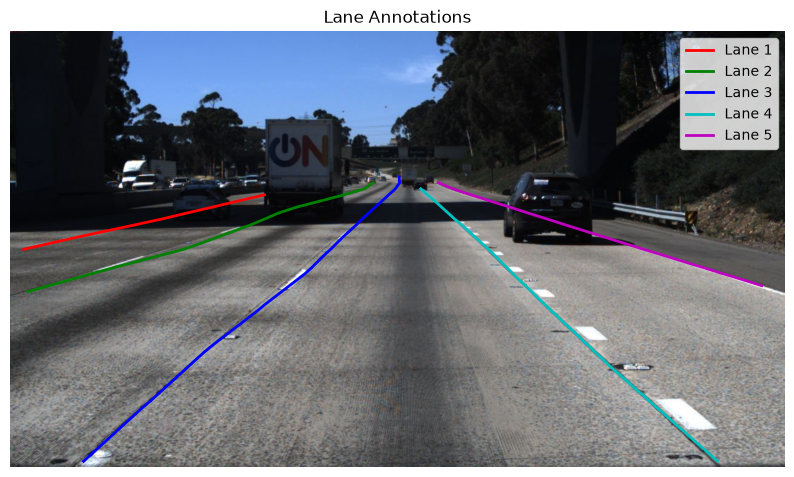

In [9]:
# Visualization function
def visualize_lanes(df=df):
    sample = df.sample(1).iloc[0]
    
    # Try train directory, fallback to test directory
    img_path = TRAIN_SET_DIR / sample['raw_file']
    if not img_path.exists():
        img_path = TEST_SET_DIR / sample['raw_file']
        
    img = cv2.imread(str(img_path))
    if img is None:
        print(f"Image not found: {img_path}")
        return
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    
    h_samples = sample['h_samples']
    lanes = sample['lanes']
    
    plt.figure(figsize=(10, 6))
    plt.imshow(img)
    
    colors = ['r', 'g', 'b', 'c', 'm', 'y']
    for i, lane in enumerate(lanes):
        x_coords = []
        y_coords = []
        for x, y in zip(lane, h_samples):
            if x != -2:
                x_coords.append(x)
                y_coords.append(y)
        plt.plot(x_coords, y_coords, color=colors[i % len(colors)], linewidth=2, label=f'Lane {i+1}')
    
    plt.legend()
    plt.title('Lane Annotations')
    plt.axis('off')
    plt.show()

# Visualize a random sample
visualize_lanes()


In [10]:
# Analyze image dimensions and brightness for a small subset
import cv2
import numpy as np

sample_size = min(100, len(df))
sample_data = df.sample(sample_size)
shapes = set()
brightness_vals = []

for d in sample_data.to_dict('records'):
    img_path = TRAIN_SET_DIR / d['raw_file']
    if not img_path.exists():
        img_path = TEST_SET_DIR / d['raw_file']
    img = cv2.imread(str(img_path))
    if img is not None:
        shapes.add(img.shape)
        # Calculate average brightness (V channel in HSV)
        hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
        brightness_vals.append(hsv[:,:,2].mean())
        
print(f"Unique image shapes in sample: {shapes}")
print(f"Average brightness (0-255): {np.mean(brightness_vals):.2f}")
print(f"Min brightness: {np.min(brightness_vals):.2f}, Max brightness: {np.max(brightness_vals):.2f}")


Unique image shapes in sample: {(720, 1280, 3)}
Average brightness (0-255): 106.92
Min brightness: 68.04, Max brightness: 131.56


##### Missing markings: 
    represented by -2 in the coordinates
##### Resolution:
    he original shape is 1280x720 (a perfect 16:9 ratio). This means that downscaling exactly by half to 512x288 is our ideal target resolution. It will save VRAM while preserving the aspect ratio perfectly and avoiding any geometric distortion of the lanes!

## Phase 2: Statistical & Visual Dataset Analysis
**Objective:** Analyze lane sparsity, geometric complexity, and environmental variance to make data-driven decisions on model architecture.

Average visible lanes per image: 3.71
Max visible lanes in an image: 5
Min visible lanes in an image: 2


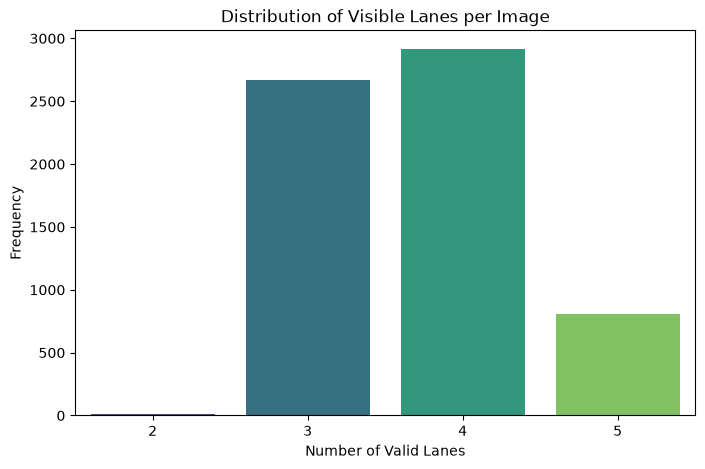

In [11]:

df['num_lanes'] = df['lanes'].apply(lambda lanes: sum(1 for lane in lanes if any(x != -2 for x in lane)))

print(f"Average visible lanes per image: {df['num_lanes'].mean():.2f}")
print(f"Max visible lanes in an image: {df['num_lanes'].max()}")
print(f"Min visible lanes in an image: {df['num_lanes'].min()}")

# Visualize

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x='num_lanes', palette='viridis',)
plt.title('Distribution of Visible Lanes per Image')
plt.xlabel('Number of Valid Lanes')
plt.ylabel('Frequency')
plt.show()


In [12]:
# Filter the dataframe for images with exactly 2 visible lanes
two_lane_df = df[df['num_lanes'] == 2]

print(f"Total images with exactly 2 lanes: {len(two_lane_df)}\n")

# Iterate through the first 3 examples to inspect the arrays
for idx, row in two_lane_df.head(3).iterrows():
    print(f"--- Image Index: {idx} | File: {row['raw_file']} ---")
    
    # Loop through each lane array in that image
    for i, lane in enumerate(row['lanes']):
        # Grab only the first 15 points so it fits on your screen
        preview = str(lane[:15]) + " ..."
        
        # Check if it's a real lane or a padded lane
        if any(x != -2 for x in lane):
            print(f"Lane {i+1} (REAL):    {preview}")
        else:
            print(f"Lane {i+1} (PADDING): {preview}")
            
    print("\n") # Add spacing between images

del two_lane_df  # Clean up memory if not needed anymore

Total images with exactly 2 lanes: 10

--- Image Index: 541 | File: clips/0313-1/17780/20.jpg ---
Lane 1 (REAL):    [637, 627, 617, 607, 597, 587, 577, 567, 557, 547, 537, 526, 516, 506, 496] ...
Lane 2 (REAL):    [-2, -2, 704, 715, 725, 735, 746, 756, 767, 777, 788, 798, 809, 819, 830] ...
Lane 3 (PADDING): [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2] ...
Lane 4 (PADDING): [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2] ...


--- Image Index: 1032 | File: clips/0313-1/17940/20.jpg ---
Lane 1 (REAL):    [-2, 631, 620, 608, 596, 584, 573, 561, 549, 538, 526, 514, 503, 491, 479] ...
Lane 2 (REAL):    [-2, -2, 729, 735, 742, 749, 756, 763, 769, 776, 783, 790, 797, 804, 810] ...
Lane 3 (PADDING): [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2] ...
Lane 4 (PADDING): [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2, -2] ...


--- Image Index: 1033 | File: clips/0313-1/17960/20.jpg ---
Lane 1 (REAL):    [-2, 629, 617, 606, 594, 583, 571, 560, 5

In [13]:
# Filter for images with exactly 5 visible lanes
five_lane_df = df[df['num_lanes'] == 5]

if len(five_lane_df) > 0:
    # Grab the very first image that has 5 lanes
    row = five_lane_df.iloc[0]
    total_slots = len(row['lanes'])
    
    print(f"File: {row['raw_file']}")
    print(f"Total Lane Slots in JSON: {total_slots}")
    print(f"Actual Visible Lanes: 5")
    print(f"Fake Padding Lanes: {total_slots - 5}")
    
    print("\n--- Array Preview ---")
    for i, lane in enumerate(row['lanes']):
        preview = str(lane[:10]) + " ..."
        print(f"Lane {i+1}: {preview}")
else:
    print("There are no images with 5 visible lanes in this dataset!")

del five_lane_df  # Clean up memory if not needed anymore

File: clips/0601/1494453515596795530/20.jpg
Total Lane Slots in JSON: 5
Actual Visible Lanes: 5
Fake Padding Lanes: 0

--- Array Preview ---
Lane 1: [-2, -2, -2, -2, -2, -2, -2, -2, 552, 530] ...
Lane 2: [-2, -2, -2, -2, -2, -2, -2, -2, 618, 614] ...
Lane 3: [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2] ...
Lane 4: [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2] ...
Lane 5: [-2, -2, -2, -2, -2, -2, -2, -2, -2, -2] ...


In [14]:
# Missing points analysis
def calculate_missing_percentage(lanes):
    total_points = 0
    missing_points = 0
    
    for lane in lanes:
        if any(x!=2 for x in lane):     # Only consider lanes that have at least one valid point
            total_points += len(lane)
            missing_points += lane.count(-2)
            
    # Avoid division by zero if an image somehow has zero valid lanes
    if total_points == 0:
        return 0.0
        
    return (missing_points / total_points) * 100

# Apply the function to create a new column
df['occlusion_pct'] = df['lanes'].apply(calculate_missing_percentage)

print(f"Average Occlusion (Missing Points) across dataset: {df['occlusion_pct'].mean():.2f}%")
print(f"Max Occlusion in a single image: {df['occlusion_pct'].max():.2f}%")

Average Occlusion (Missing Points) across dataset: 40.05%
Max Occlusion in a single image: 71.35%


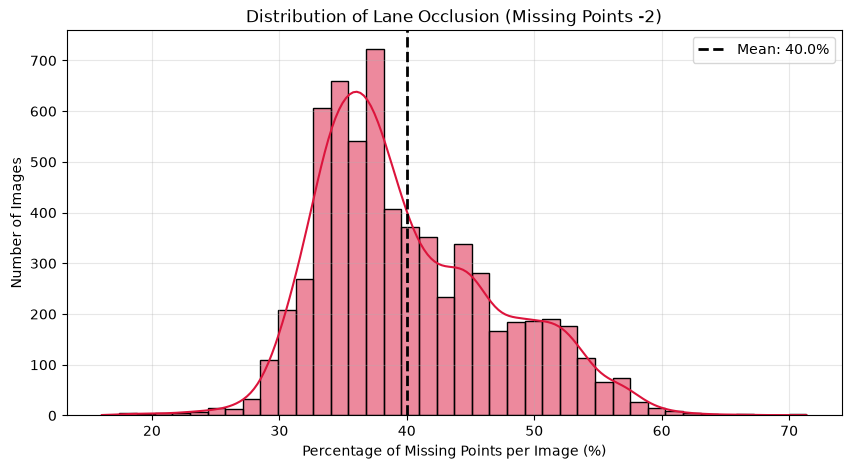

In [15]:

plt.figure(figsize=(10, 5))

# Plot the distribution of occlusion percentages
sns.histplot(data=df, x='occlusion_pct', bins=40, kde=True, color='crimson')

plt.title('Distribution of Lane Occlusion (Missing Points -2)')
plt.xlabel('Percentage of Missing Points per Image (%)')
plt.ylabel('Number of Images')

# Add a vertical line for the mean
plt.axvline(df['occlusion_pct'].mean(), color='black', linestyle='dashed', linewidth=2, 
            label=f"Mean: {df['occlusion_pct'].mean():.1f}%")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Calculating Sparsity: 0/500 processed...
Calculating Sparsity: 100/500 processed...
Calculating Sparsity: 200/500 processed...
Calculating Sparsity: 300/500 processed...
Calculating Sparsity: 400/500 processed...


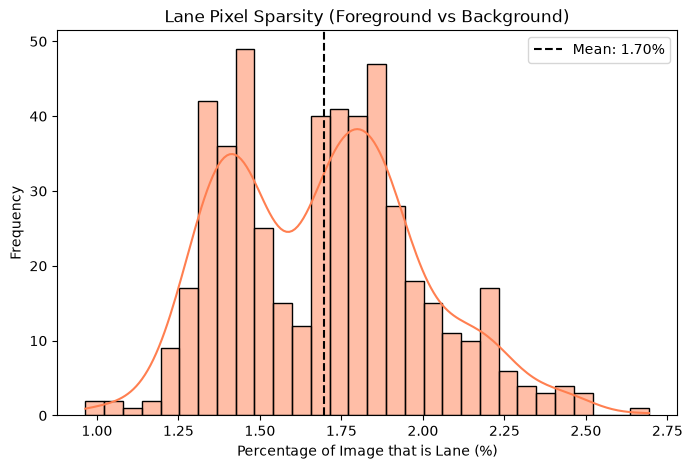

In [21]:
sparsity_ratios = []
# Sample 500 images to make this run fast in EDA
sample_df = df.sample(n=500, random_state=42)

total_samples = len(sample_df)
for idx, (idx_df, row) in enumerate(sample_df.iterrows()):
    if idx % 100 == 0:
        print(f"Calculating Sparsity: {idx}/{total_samples} processed...")
    img_path = TRAIN_SET_DIR / row['raw_file']
    if not img_path.exists():
        img_path = TEST_SET_DIR / row['raw_file']
    
    img = cv2.imread(str(img_path))
    if img is None: continue
        
    h, w = img.shape[:2]
    # Create a blank black mask
    mask = np.zeros((h, w), dtype=np.uint8)
    
    # Extract valid lanes using our corrected logic
    for lane_x in row['lanes']:
        # Skip fake padded lanes!
        if not any(x != -2 for x in lane_x):
            continue
            
        # Get actual x, y coordinate pairs
        pts = [(x, y) for x, y in zip(lane_x, row['h_samples']) if x != -2]
        if len(pts) > 1:
            # Draw the lane with a realistic thickness (5 pixels)
            cv2.polylines(mask, [np.array(pts, dtype=np.int32)], isClosed=False, color=255, thickness=5)
            
    # Calculate percentage of white pixels vs total pixels
    lane_pixels = np.count_nonzero(mask)
    total_pixels = h * w
    sparsity_ratios.append((lane_pixels / total_pixels) * 100)
    
# Visualization
plt.figure(figsize=(8, 5))
sns.histplot(sparsity_ratios, bins=30, kde=True, color='coral')
plt.title('Lane Pixel Sparsity (Foreground vs Background)')
plt.xlabel('Percentage of Image that is Lane (%)')
plt.ylabel('Frequency')
plt.axvline(np.mean(sparsity_ratios), color='black', linestyle='--', label=f'Mean: {np.mean(sparsity_ratios):.2f}%')
plt.legend()
plt.show()


## Final EDA Conclusions & Architectural Decisions

Based on the statistical analysis of the TuSimple dataset, we have established the exact parameters required to train a high-FPS lane detection model within an 8GB VRAM constraint (optimized for RTX 4060).

### 1. Key Dataset Findings
* **Resolution & Aspect Ratio:** The original 1280x720 (16:9) images are downscaled to **512x288** (preserving the exact 16:9 aspect ratio to prevent geometric distortion of lanes). This reduces input dimensions by 84%, dramatically lowering VRAM consumption and accelerating inference.
* **Spatial Complexity & Class Imbalance:** The lanes occupy less than 2% of the image space, representing an extreme background-to-foreground class imbalance. 
* **Coordinate Sparsity:** Ground truth annotations have an average missing coordinate rate of **40.05%** (with points marked as `-2` due to occlusion, dashed lines, and distance cut-offs).

---

### 2. Mandatory Engineering Decisions

* **Model Architecture:** We implement a **UNet architecture with a MobileNetV2 encoder backbone** (approx. 2.92M parameters). The backbone is kept frozen during Stage 1 (warm-up) and fine-tuned in Stage 2. This keeps the memory footprint low and achieves high FPS, avoiding heavy architectures while leveraging pretrained features.
* **Objective & Loss Function:** To address the severe class imbalance and ignore the coordinate sparsity (`-2` padding), we train the model on thick-5 pixel binary segmentation masks using a **combined Focal + Dice Loss (`combo_loss`)**. This ensures the model focuses on learning lane geometry without being biased by the dominant background class.
* **Augmentations & Generalization:** To improve training stability and robustness:
  * **Photometric Augmentations:** Random brightness and contrast adjustments are applied to simulate varying time-of-day lighting conditions.
  * **Geometric Augmentations:** Random horizontal flips are performed to prevent road bias.
  * We skip resource-heavy spatial augmentations to keep the data pipeline fast and bound to CPU limitations.

